In [120]:
# ===== 1) Preparação =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def read_csv_robust(path):
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise last_err

train = read_csv_robust(Path("datasets/training_data.csv"))

# Converter datas
train["record_date"] = pd.to_datetime(train["record_date"], errors="coerce")
train["hour"] = train["record_date"].dt.hour
train["dayofweek"] = train["record_date"].dt.dayofweek
dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
train["dow_name"] = train["dayofweek"].map(dow_map)

# Velocidade real (quanto menor → mais trânsito)
train["real_speed"] = train["AVERAGE_FREE_FLOW_SPEED"] - train["AVERAGE_TIME_DIFF"]
train.loc[train["real_speed"] < 0, "real_speed"] = np.nan


In [121]:
# ===== 2) Cálculo da velocidade real média =====
# Calcular velocidade real média:
# diferença = velocidade_livre - velocidade_real  => velocidade_real = velocidade_livre - diferença
train["real_speed"] = train["AVERAGE_FREE_FLOW_SPEED"] - train["AVERAGE_TIME_DIFF"]

# Remover possíveis valores negativos ou absurdos
train.loc[train["real_speed"] < 0, "real_speed"] = np.nan

train[["record_date", "AVERAGE_FREE_FLOW_SPEED", "AVERAGE_TIME_DIFF", "real_speed"]].head()

,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,real_speed
0,2019-08-29 07:00:00,41.5,11.5,30.0
1,2018-08-10 14:00:00,41.7,48.3,NaN
2,2019-09-01 16:00:00,38.6,38.4,0.2
3,2019-02-26 11:00:00,37.4,61.0,NaN
4,2019-06-06 12:00:00,41.6,50.4,NaN


As horas onde a linha desce → velocidade menor → mais trânsito.
As horas onde a linha sobe → trânsito fluido.

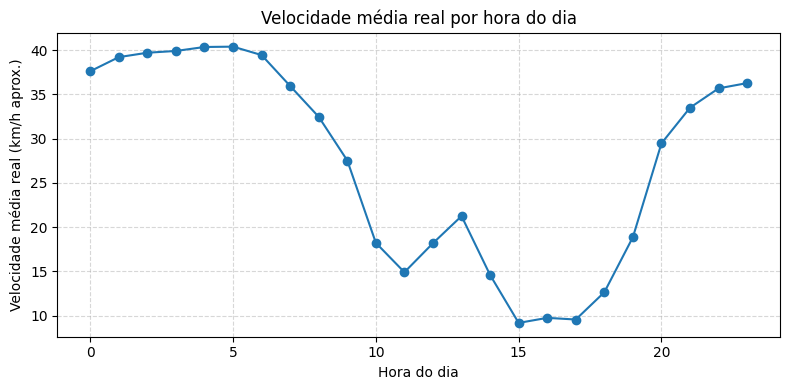

In [122]:
# ===== 2) Velocidade média por hora =====
hourly_speed = train.groupby("hour")["real_speed"].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(hourly_speed["hour"], hourly_speed["real_speed"], marker="o")
plt.title("Velocidade média real por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Velocidade média real (km/h aprox.)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Dias com barras mais baixas → média de velocidade menor → mais congestionamento (ex: 2ª–6ª).
Dias com barras altas → menos trânsito (ex: fim-de-semana).

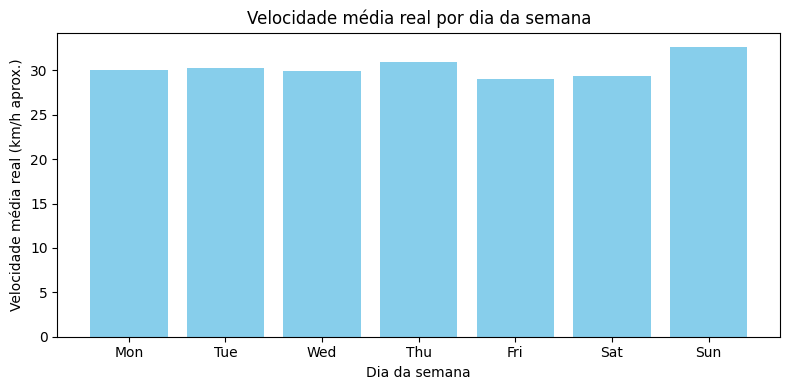

In [123]:
# ===== 3) Velocidade média por dia da semana =====
dow_speed = train.groupby("dow_name")["real_speed"].mean().reindex(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
).reset_index()

plt.figure(figsize=(8,4))
plt.bar(dow_speed["dow_name"], dow_speed["real_speed"], color="skyblue")
plt.title("Velocidade média real por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Velocidade média real (km/h aprox.)")
plt.tight_layout()
plt.show()


As áreas mais vermelhas indicam velocidades baixas (mais trânsito).
As áreas azuladas indicam velocidades altas (menos trânsito).
Como é previsto vamos ver picos de congestionamento nas manhãs e fins de tarde dos dias úteis.

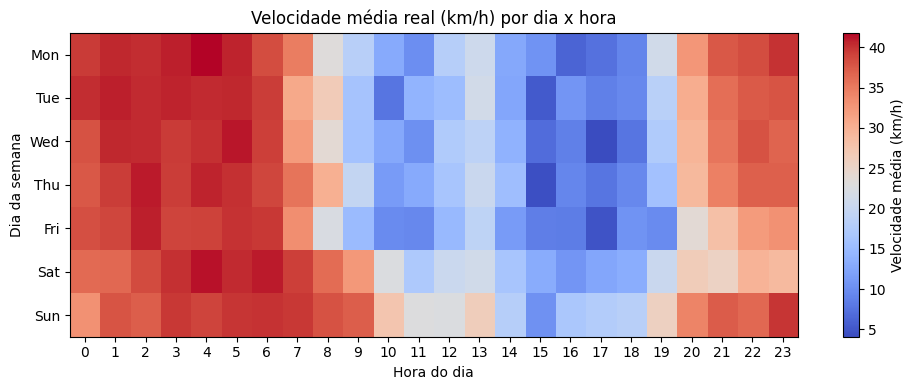

In [124]:
# ===== 4) Heatmap de velocidade média (dia x hora) =====
pivot_speed = (
    train.pivot_table(index="dow_name", columns="hour", values="real_speed", aggfunc="mean")
         .reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)

plt.figure(figsize=(10,4))
plt.imshow(pivot_speed, aspect="auto", cmap="coolwarm", origin="upper")
plt.title("Velocidade média real (km/h) por dia x hora")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.xticks(np.arange(0,24), np.arange(0,24))
plt.yticks(ticks=np.arange(7), labels=pivot_speed.index)
plt.colorbar(label="Velocidade média (km/h)")
plt.tight_layout()
plt.show()


Velocidade média com e sem chuva (AVERAGE_RAIN)

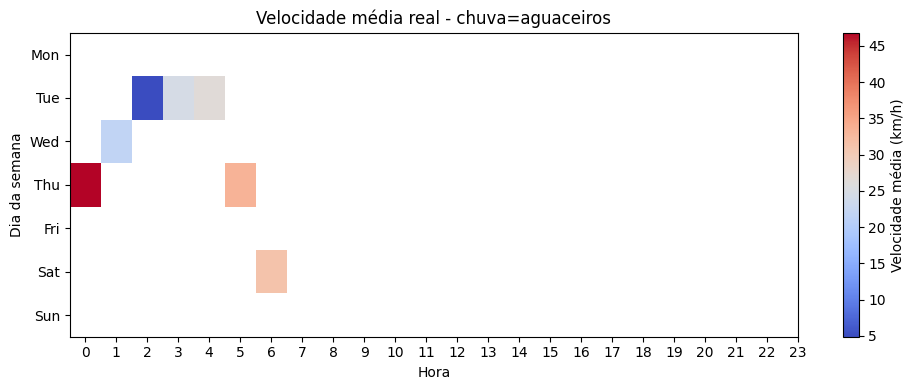

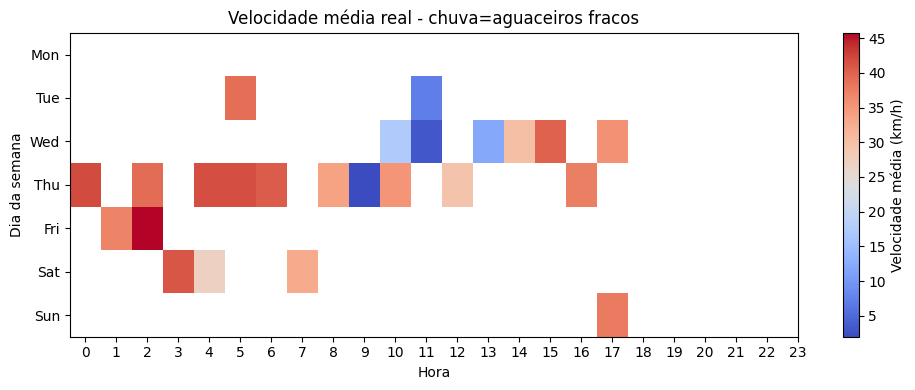

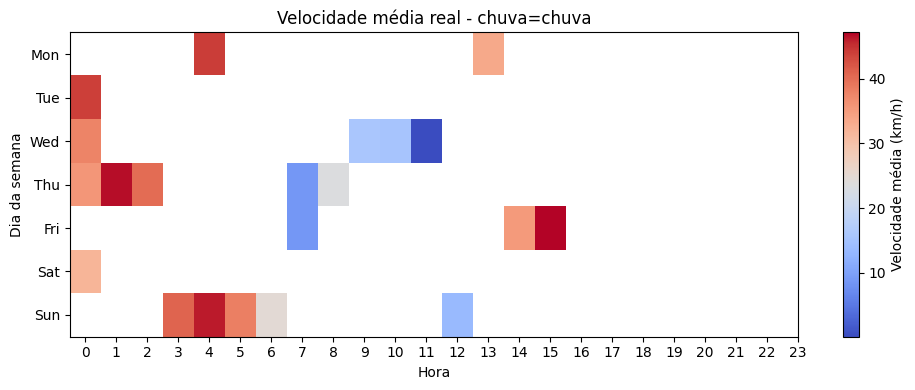

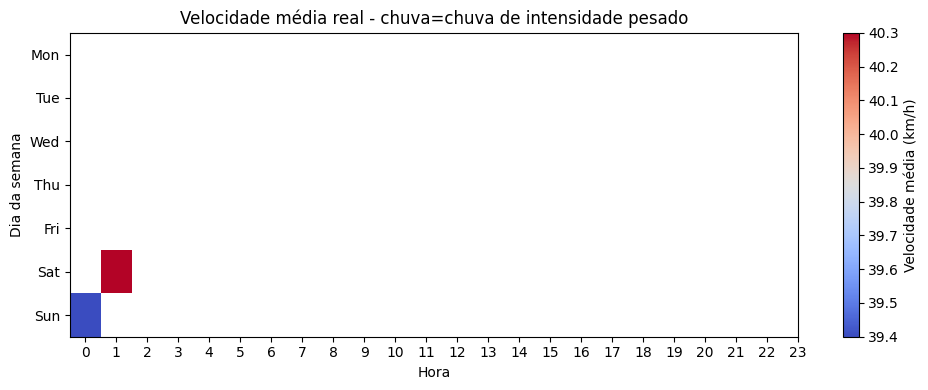

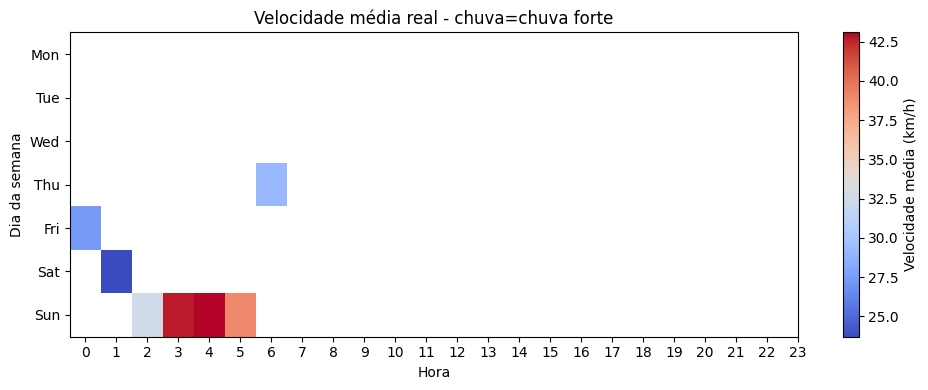

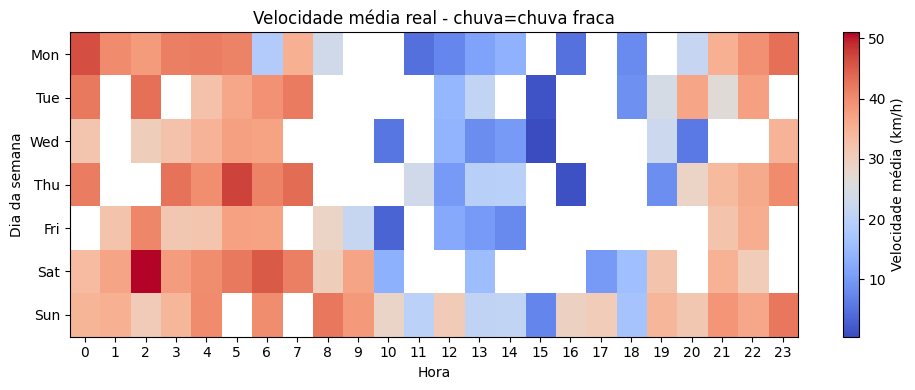

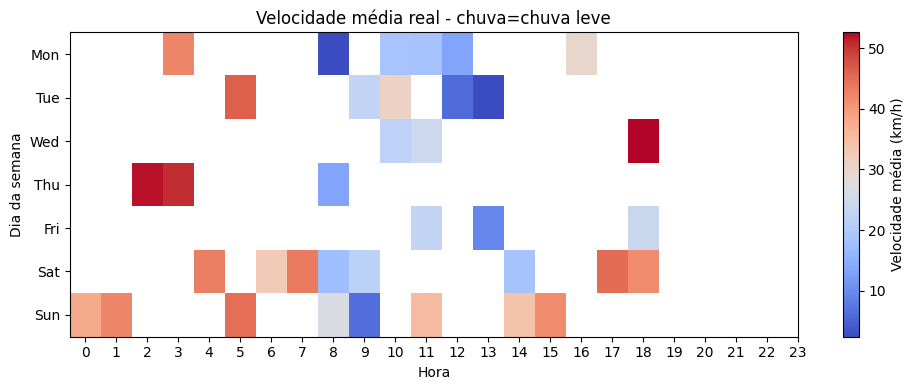

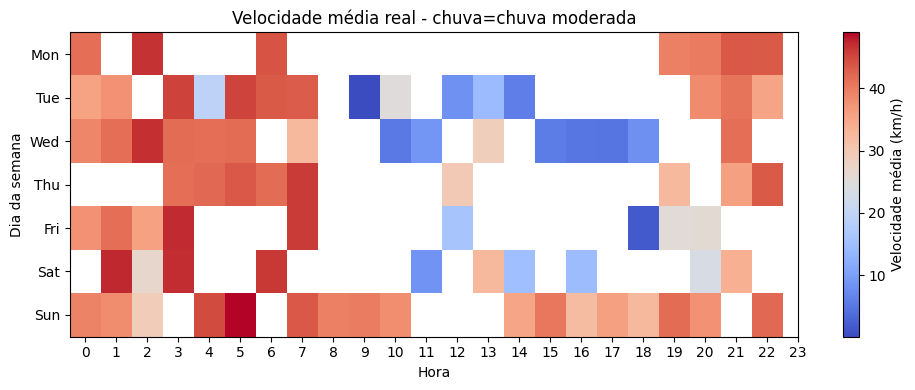

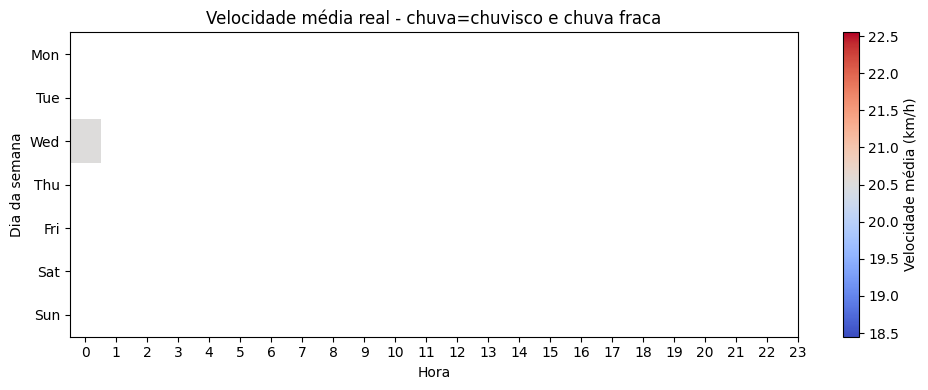

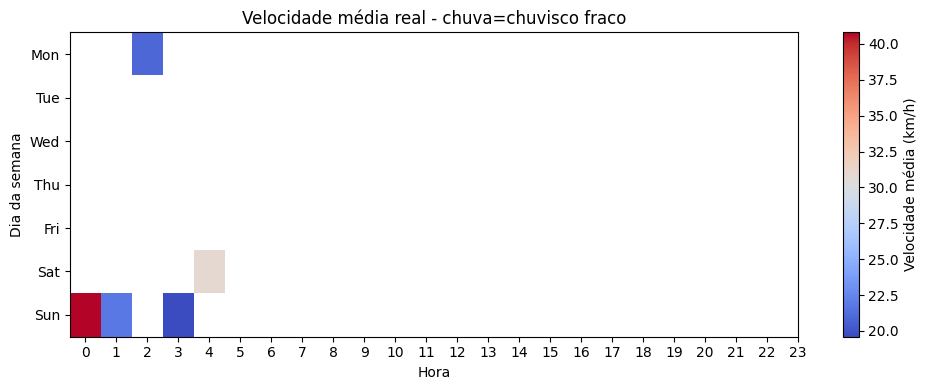

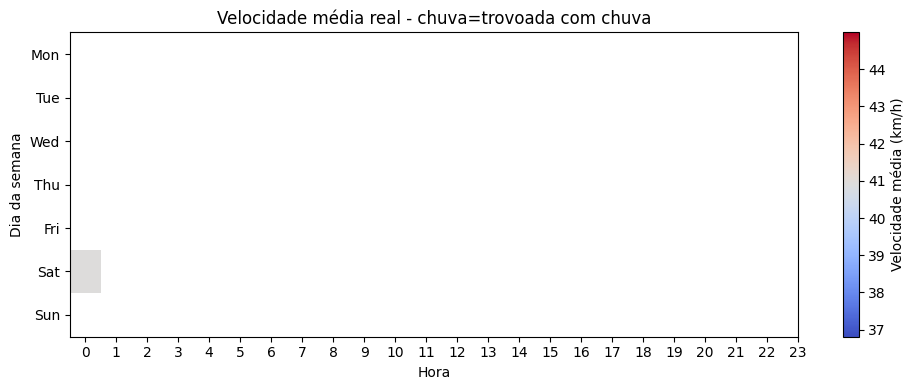

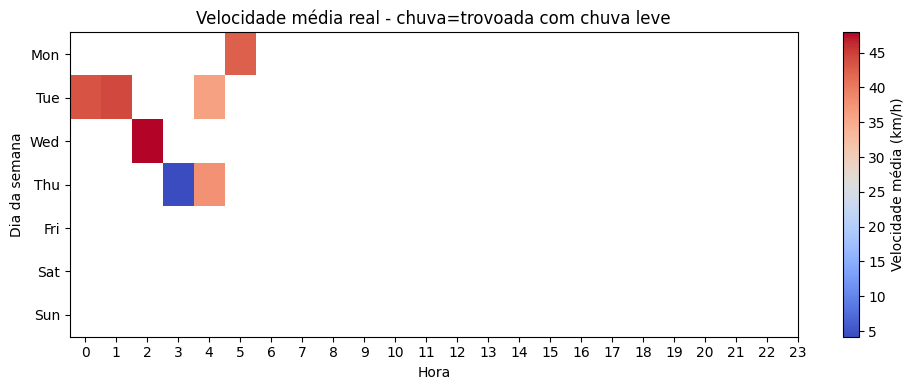

In [125]:
# ===== 3) Heatmap dia x hora - COM/SEM chuva =====
if "AVERAGE_RAIN" in train.columns:
    for rain_flag, subset in train.groupby("AVERAGE_RAIN"):
        pivot = (subset.pivot_table(index="dow_name", columns="hour", values="real_speed", aggfunc="mean")
                       .reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]))
        plt.figure(figsize=(10,4))
        plt.imshow(pivot, aspect="auto", cmap="coolwarm", origin="upper")
        plt.title(f"Velocidade média real - chuva={rain_flag}")
        plt.xlabel("Hora")
        plt.ylabel("Dia da semana")
        plt.xticks(np.arange(0,24), np.arange(0,24))
        plt.yticks(np.arange(7), pivot.index)
        plt.colorbar(label="Velocidade média (km/h)")
        plt.tight_layout()
        plt.show()


Velocidade média por nível de precipitação (AVERAGE_PRECIPITATION)

In [129]:
'''# ===== 2) Velocidade média por nível de precipitação =====
prec_bins = [-0.01, 0, 1, 5, 10, 20, np.inf]
labels = ["0", "0-1", "1-5", "5-10", "10-20", ">20"]

train["prec_bin"] = pd.cut(train["AVERAGE_PRECIPITATION"].fillna(0), bins=prec_bins, labels=labels)

prec_speed = (
    train.groupby("prec_bin")["real_speed"]
    .mean()
    .reset_index()
    .rename(columns={"real_speed": "Velocidade média"})
)


plt.figure(figsize=(8,4))
plt.plot(prec_speed["prec_bin"], prec_speed["Velocidade média"], marker="o")
plt.title("Velocidade média real por níveis de precipitação")
plt.xlabel("Precipitação (mm/hora aprox.)")
plt.ylabel("Velocidade média real (km/h)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print(prec_speed)
'''

print("Existe a coluna AVERAGE_PRECIPITATION?", "AVERAGE_PRECIPITATION" in train.columns)
print("Total de registos:", len(train))
print("Registos com precipitação > 0:", (train["AVERAGE_PRECIPITATION"] > 0).sum())



Existe a coluna AVERAGE_PRECIPITATION? True
Total de registos: 6812
Registos com precipitação > 0: 0


Velocidade média vs temperatura (AVERAGE_TEMPERATURE)

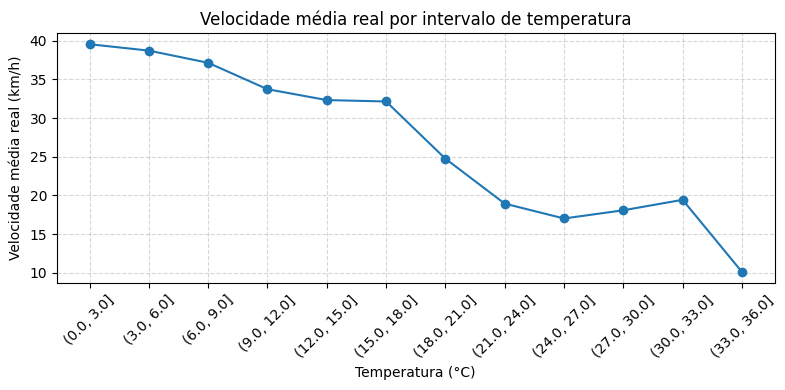

        temp_bin  Velocidade média
0     (0.0, 3.0]         39.548485
1     (3.0, 6.0]         38.720000
2     (6.0, 9.0]         37.146479
3    (9.0, 12.0]         33.728733
4   (12.0, 15.0]         32.323990
5   (15.0, 18.0]         32.142836
6   (18.0, 21.0]         24.743834
7   (21.0, 24.0]         18.931325
8   (24.0, 27.0]         17.009155
9   (27.0, 30.0]         18.069231
10  (30.0, 33.0]         19.424000
11  (33.0, 36.0]         10.100000


In [137]:
# ===== 3) Velocidade média por temperatura =====
temp_bins = np.arange(train["AVERAGE_TEMPERATURE"].min(), train["AVERAGE_TEMPERATURE"].max()+2, 3)
train["temp_bin"] = pd.cut(train["AVERAGE_TEMPERATURE"], bins=temp_bins)

temp_speed = (
    train.groupby("temp_bin", observed=False)["real_speed"]
    .mean()
    .reset_index()
    .rename(columns={"real_speed": "Velocidade média"})
)

plt.figure(figsize=(8,4))
plt.plot(temp_speed["temp_bin"].astype(str), temp_speed["Velocidade média"], marker="o")
plt.title("Velocidade média real por intervalo de temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Velocidade média real (km/h)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print(temp_speed)

Velocidade média vs vento (AVERAGE_WIND_SPEED)

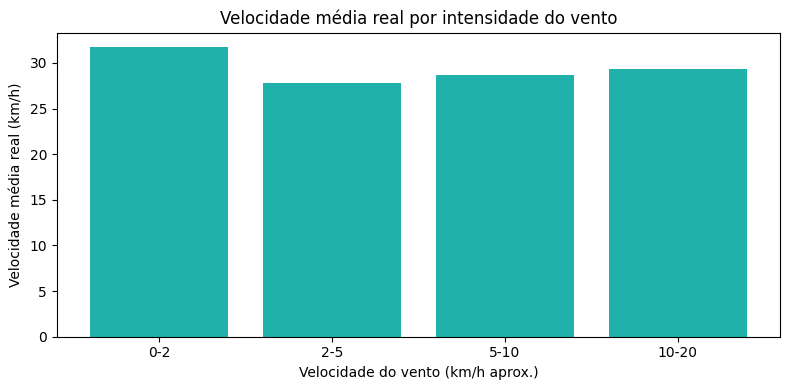

  wind_bin  Velocidade média
0      0-2         31.708759
1      2-5         27.830466
2     5-10         28.716426
3    10-20         29.310526
4      >20               NaN


In [138]:
# ===== 4) Velocidade média por vento =====
wind_bins = [0, 2, 5, 10, 20, 50]
labels = ["0-2","2-5","5-10","10-20",">20"]
train["wind_bin"] = pd.cut(train["AVERAGE_WIND_SPEED"].fillna(0), bins=wind_bins, labels=labels)

wind_speed = (
    train.groupby("wind_bin", observed=False)["real_speed"]
    .mean()
    .reset_index()
    .rename(columns={"real_speed": "Velocidade média"})
)

plt.figure(figsize=(8,4))
plt.bar(wind_speed["wind_bin"], wind_speed["Velocidade média"], color="lightseagreen")
plt.title("Velocidade média real por intensidade do vento")
plt.xlabel("Velocidade do vento (km/h aprox.)")
plt.ylabel("Velocidade média real (km/h)")
plt.tight_layout()
plt.show()

print(wind_speed)
